# YOLOv10n vs YOLOv11n vs YOLOv12n: Object Tracking Speed Comparison

**Task:** Apply object tracking on a single road / motorway video with three nano-scale YOLO detectors and compare their inference speed.

**Tracker:** ByteTrack (held constant across all three detectors so the comparison reflects detector cost, not tracker cost).

**Honest caveats up front:**

1. A single short video is a noisy benchmark. We mitigate this with a warmup pass and by reporting **mean, median, std, p95**.
2. The three nano models are architecturally similar in scale. Expect single-digit percentage differences.
3. `imgsz`, `half` precision, batch size, and device all dominate the comparison. We hold them constant.
4. YOLOv12 weights are loaded via Ultralytics. If `yolo12n.pt` cannot be resolved, the notebook falls back gracefully.
5. `model.track()` includes detection **and** tracking. We separately benchmark `model.predict()` to isolate pure detector cost.

**Outputs (all written to `/kaggle/working/`):**
- Annotated tracking videos for each model (`*_tracked.mp4`)
- Per-frame timing CSV for each model
- Aggregate comparison JSON (`speed_comparison.json`)
- Plots: per-frame inference time, FPS bar chart, timing-stage breakdown, FPS distribution, cumulative time
- Sample annotated frames per model
- Final markdown report (`REPORT.md`)

## 1. Environment Setup

In [1]:
import subprocess, sys

def pip_install(pkgs):
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', *pkgs],
        check=False
    )

pip_install(['ultralytics>=8.3.0', 'lap>=0.5.12'])
print('Install step done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.4 MB/s eta 0:00:00
Install step done.


In [2]:
import os, json, time, math, shutil, platform, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib

import ultralytics
from ultralytics import YOLO

warnings.filterwarnings('ignore', category=UserWarning)

print('Python      :', platform.python_version())
print('Torch       :', torch.__version__)
print('CUDA avail  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('CUDA device :', torch.cuda.get_device_name(0))
    print('CUDA version:', torch.version.cuda)
print('Ultralytics :', ultralytics.__version__)
print('OpenCV      :', cv2.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python      : 3.12.12
Torch       : 2.10.0+cu128
CUDA avail  : True
CUDA device : Tesla T4
CUDA version: 12.8
Ultralytics : 8.4.45
OpenCV      : 4.13.0


## 2. Configuration

All knobs that affect the comparison live here. Change one thing at a time if you re-run.

In [3]:
# --- Paths ---
INPUT_VIDEO = '/kaggle/input/datasets/amryasser226/test-video/Test.mp4'
OUTPUT_DIR  = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FRAMES_DIR  = OUTPUT_DIR / 'sample_frames'
PLOTS_DIR   = OUTPUT_DIR / 'plots'
LOGS_DIR    = OUTPUT_DIR / 'per_frame_logs'
for d in (FRAMES_DIR, PLOTS_DIR, LOGS_DIR):
    d.mkdir(exist_ok=True)

# --- Models to compare ---
MODELS = {
    'YOLOv10n': 'yolov10n.pt',
    'YOLOv11n': 'yolo11n.pt',
    'YOLOv12n': 'yolo12n.pt',
}

# --- Inference settings (held constant across all models) ---
IMG_SIZE   = 640
CONF_THRES = 0.25
IOU_THRES  = 0.45
DEVICE     = 0 if torch.cuda.is_available() else 'cpu'
HALF       = torch.cuda.is_available()
TRACKER    = 'bytetrack.yaml'
WARMUP_FRAMES = 30

# Vehicle-related COCO classes only
VEHICLE_CLASSES = [2, 3, 5, 7]  # car, motorcycle, bus, truck

# Sanity check input video exists
if not os.path.exists(INPUT_VIDEO):
    raise FileNotFoundError(
        f'Input video not found at {INPUT_VIDEO}. '
        'Double-check the dataset is attached to the Kaggle notebook.'
    )

# Probe video metadata
cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    raise RuntimeError(f'OpenCV could not open {INPUT_VIDEO}')
VIDEO_META = {
    'width':  int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
    'height': int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    'fps':    float(cap.get(cv2.CAP_PROP_FPS)),
    'frame_count': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
}
cap.release()
VIDEO_META['duration_sec'] = (
    VIDEO_META['frame_count'] / VIDEO_META['fps'] if VIDEO_META['fps'] else None
)
print('Video metadata:')
for k, v in VIDEO_META.items():
    print(f'  {k:<12}: {v}')
print(f'\nDevice: {DEVICE} | half={HALF} | imgsz={IMG_SIZE} | conf={CONF_THRES}')

Video metadata:
  width       : 1280
  height      : 720
  fps         : 30.0
  frame_count : 942
  duration_sec: 31.4

Device: 0 | half=True | imgsz=640 | conf=0.25


## 3. Sample Frame Preview

A quick look at what we're tracking.

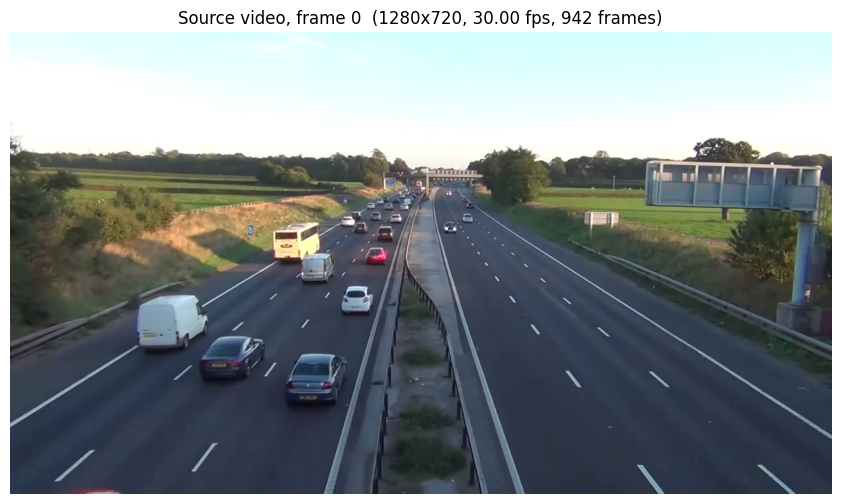

Saved: /kaggle/working/plots/00_source_first_frame.png


In [4]:
cap = cv2.VideoCapture(INPUT_VIDEO)
ok, frame = cap.read()
cap.release()
if not ok:
    raise RuntimeError('Could not read first frame.')

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.imshow(frame_rgb)
plt.title(f"Source video, frame 0  ({VIDEO_META['width']}x{VIDEO_META['height']}, "
          f"{VIDEO_META['fps']:.2f} fps, {VIDEO_META['frame_count']} frames)")
plt.axis('off')
preview_path = PLOTS_DIR / '00_source_first_frame.png'
plt.savefig(preview_path, dpi=110, bbox_inches='tight')
plt.show()
print('Saved:', preview_path)

## 4. Load Models

Each model is loaded once and reused. Failures are caught and reported.

In [5]:
loaded_models = {}
load_errors   = {}

for name, weights in MODELS.items():
    try:
        t0 = time.perf_counter()
        m  = YOLO(weights)
        if torch.cuda.is_available():
            m.to('cuda:0')
        load_time = time.perf_counter() - t0
        try:
            n_params = sum(p.numel() for p in m.model.parameters())
        except Exception:
            n_params = None
        loaded_models[name] = {'model': m, 'weights': weights,
                               'load_time_s': load_time, 'params': n_params}
        print(f'[OK]   {name:<10} weights={weights:<14} '
              f'params={n_params:,} load={load_time:.2f}s')
    except Exception as e:
        load_errors[name] = repr(e)
        print(f'[FAIL] {name:<10} weights={weights}  ->  {e}')

if not loaded_models:
    raise RuntimeError('No models loaded successfully — cannot continue.')

[OK]   YOLOv10n   weights=yolov10n.pt    params=2,775,520 load=0.52s
[OK]   YOLOv11n   weights=yolo11n.pt     params=2,624,080 load=0.33s
[OK]   YOLOv12n   weights=yolo12n.pt     params=2,603,056 load=0.26s


## 5. Benchmark Functions

For each model we:

1. **Warm up** by running detection on the first `WARMUP_FRAMES` frames. Times here are discarded.
2. Run a **pure-detection pass** (`predict`) over the full video, recording `preprocess_ms`, `inference_ms`, `postprocess_ms` per frame.
3. Run a **tracking pass** (`track` with ByteTrack), recording per-frame total time and writing an annotated `mp4`.

We use `torch.cuda.synchronize()` around each call when on GPU — without sync, async CUDA launches make the timer lie.

In [6]:
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def iter_frames(path):
    cap = cv2.VideoCapture(path)
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        yield fr
    cap.release()


def warmup(model, n_frames=WARMUP_FRAMES):
    count = 0
    for fr in iter_frames(INPUT_VIDEO):
        if count >= n_frames:
            break
        _ = model.predict(
            fr, imgsz=IMG_SIZE, conf=CONF_THRES, iou=IOU_THRES,
            device=DEVICE, half=HALF, classes=VEHICLE_CLASSES, verbose=False,
        )
        count += 1
    cuda_sync()


def benchmark_predict(model_name, model):
    rows = []
    for idx, fr in enumerate(iter_frames(INPUT_VIDEO)):
        cuda_sync()
        t0 = time.perf_counter()
        results = model.predict(
            fr, imgsz=IMG_SIZE, conf=CONF_THRES, iou=IOU_THRES,
            device=DEVICE, half=HALF, classes=VEHICLE_CLASSES, verbose=False,
        )
        cuda_sync()
        wall_ms = (time.perf_counter() - t0) * 1000.0
        sp = results[0].speed
        n_det = 0 if results[0].boxes is None else len(results[0].boxes)
        rows.append({
            'frame': idx,
            'wall_ms':        wall_ms,
            'preprocess_ms':  float(sp.get('preprocess', float('nan'))),
            'inference_ms':   float(sp.get('inference',  float('nan'))),
            'postprocess_ms': float(sp.get('postprocess', float('nan'))),
            'detections':     n_det,
        })
    df = pd.DataFrame(rows)
    df['fps_wall'] = 1000.0 / df['wall_ms']
    return df


def benchmark_track_and_render(model_name, model, output_video_path):
    cap = cv2.VideoCapture(INPUT_VIDEO)
    fps_in = cap.get(cv2.CAP_PROP_FPS) or 25.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_video_path), fourcc, fps_in, (w, h))
    rows = []
    unique_track_ids = set()
    idx = 0
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        cuda_sync()
        t0 = time.perf_counter()
        results = model.track(
            fr, imgsz=IMG_SIZE, conf=CONF_THRES, iou=IOU_THRES,
            device=DEVICE, half=HALF, classes=VEHICLE_CLASSES,
            tracker=TRACKER, persist=True, verbose=False,
        )
        cuda_sync()
        wall_ms = (time.perf_counter() - t0) * 1000.0
        r = results[0]
        sp = r.speed
        n_det = 0 if r.boxes is None else len(r.boxes)
        if r.boxes is not None and r.boxes.id is not None:
            ids = r.boxes.id.int().cpu().tolist()
            unique_track_ids.update(ids)
        annotated = r.plot()
        cv2.putText(annotated, f'{model_name}  {1000.0/wall_ms:5.1f} FPS',
                    (12, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        writer.write(annotated)
        rows.append({
            'frame': idx,
            'wall_ms':        wall_ms,
            'preprocess_ms':  float(sp.get('preprocess', float('nan'))),
            'inference_ms':   float(sp.get('inference',  float('nan'))),
            'postprocess_ms': float(sp.get('postprocess', float('nan'))),
            'detections':     n_det,
        })
        idx += 1
    cap.release()
    writer.release()
    df = pd.DataFrame(rows)
    df['fps_wall'] = 1000.0 / df['wall_ms']
    return df, len(unique_track_ids)

## 6. Run Benchmarks (per model)

In [7]:
predict_dfs = {}
track_dfs   = {}
unique_ids  = {}
runtime_failures = {}

for name, info in loaded_models.items():
    print(f'\n=== {name} ===')
    model = info['model']
    try:
        print('  warmup...')
        warmup(model)

        print('  predict pass...')
        pdf = benchmark_predict(name, model)
        predict_dfs[name] = pdf
        pdf.to_csv(LOGS_DIR / f'{name}_predict_per_frame.csv', index=False)
        print(f"    frames={len(pdf)}  mean_inf={pdf['inference_ms'].mean():.2f} ms"
              f"  mean_wall={pdf['wall_ms'].mean():.2f} ms"
              f"  mean_FPS={pdf['fps_wall'].mean():.2f}")

        print('  track pass + render...')
        out_vid = OUTPUT_DIR / f'{name}_tracked.mp4'
        tdf, n_ids = benchmark_track_and_render(name, model, out_vid)
        track_dfs[name] = tdf
        unique_ids[name] = n_ids
        tdf.to_csv(LOGS_DIR / f'{name}_track_per_frame.csv', index=False)
        print(f"    frames={len(tdf)}  mean_wall={tdf['wall_ms'].mean():.2f} ms"
              f"  mean_FPS={tdf['fps_wall'].mean():.2f}  unique_track_ids={n_ids}")
        print(f'    saved video: {out_vid}')

    except Exception as e:
        runtime_failures[name] = repr(e)
        print(f'  [FAIL] {e}')

print('\nDone. Failures:', runtime_failures or 'none')


=== YOLOv10n ===
  warmup...
  predict pass...
    frames=942  mean_inf=9.24 ms  mean_wall=11.78 ms  mean_FPS=85.13
  track pass + render...
    frames=942  mean_wall=16.16 ms  mean_FPS=64.18  unique_track_ids=200
    saved video: /kaggle/working/YOLOv10n_tracked.mp4

=== YOLOv11n ===
  warmup...
  predict pass...
    frames=942  mean_inf=9.38 ms  mean_wall=12.81 ms  mean_FPS=78.25
  track pass + render...
    frames=942  mean_wall=16.55 ms  mean_FPS=60.61  unique_track_ids=184
    saved video: /kaggle/working/YOLOv11n_tracked.mp4

=== YOLOv12n ===
  warmup...
  predict pass...
    frames=942  mean_inf=14.57 ms  mean_wall=18.10 ms  mean_FPS=55.33
  track pass + render...
    frames=942  mean_wall=21.09 ms  mean_FPS=47.57  unique_track_ids=149
    saved video: /kaggle/working/YOLOv12n_tracked.mp4

Done. Failures: none


## 7. Aggregate Statistics

Mean alone is misleading because of CUDA tail latency on the first few frames and occasional GC stalls. We report mean, median, std, and p95.

In [8]:
def summarize(df, label):
    if df is None or df.empty:
        return None
    return {
        'label':               label,
        'frames':              int(len(df)),
        'wall_ms_mean':        float(df['wall_ms'].mean()),
        'wall_ms_median':      float(df['wall_ms'].median()),
        'wall_ms_std':         float(df['wall_ms'].std()),
        'wall_ms_p95':         float(df['wall_ms'].quantile(0.95)),
        'inference_ms_mean':   float(df['inference_ms'].mean()),
        'inference_ms_median': float(df['inference_ms'].median()),
        'preprocess_ms_mean':  float(df['preprocess_ms'].mean()),
        'postprocess_ms_mean': float(df['postprocess_ms'].mean()),
        'fps_wall_mean':       float(df['fps_wall'].mean()),
        'fps_wall_median':     float(df['fps_wall'].median()),
        'total_wall_s':        float(df['wall_ms'].sum() / 1000.0),
        'mean_detections':     float(df['detections'].mean()),
    }


summary = {
    'video':   VIDEO_META,
    'config': {
        'imgsz': IMG_SIZE, 'conf': CONF_THRES, 'iou': IOU_THRES,
        'device': str(DEVICE), 'half': HALF, 'tracker': TRACKER,
        'vehicle_classes': VEHICLE_CLASSES,
        'warmup_frames': WARMUP_FRAMES,
        'ultralytics': ultralytics.__version__,
        'torch': torch.__version__,
        'cuda': torch.version.cuda if torch.cuda.is_available() else None,
        'gpu':  torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    },
    'load_errors':      load_errors,
    'runtime_failures': runtime_failures,
    'models': {},
}

for name in MODELS:
    block = {
        'weights': MODELS[name],
        'params':  loaded_models.get(name, {}).get('params'),
        'load_time_s': loaded_models.get(name, {}).get('load_time_s'),
        'predict': summarize(predict_dfs.get(name), f'{name}-predict'),
        'track':   summarize(track_dfs.get(name),   f'{name}-track'),
        'unique_track_ids': unique_ids.get(name),
    }
    summary['models'][name] = block

json_path = OUTPUT_DIR / 'speed_comparison.json'
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved:', json_path)

rows = []
for name, b in summary['models'].items():
    if b['predict'] and b['track']:
        rows.append({
            'Model':              name,
            'Params':             b['params'],
            'Predict mean ms':    round(b['predict']['wall_ms_mean'], 2),
            'Predict mean FPS':   round(b['predict']['fps_wall_mean'], 2),
            'Predict p95 ms':     round(b['predict']['wall_ms_p95'],  2),
            'Track mean ms':      round(b['track']['wall_ms_mean'],   2),
            'Track mean FPS':     round(b['track']['fps_wall_mean'],  2),
            'Track p95 ms':       round(b['track']['wall_ms_p95'],    2),
            'Total track time s': round(b['track']['total_wall_s'],   2),
            'Tracks':             b['unique_track_ids'],
        })
comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(OUTPUT_DIR / 'comparison_table.csv', index=False)
comparison_df

Saved: /kaggle/working/speed_comparison.json


,Model,Params,Predict mean ms,Predict mean FPS,Predict p95 ms,Track mean ms,Track mean FPS,Track p95 ms,Total track time s,Tracks
0,YOLOv10n,2775520,11.78,85.13,12.63,16.16,64.18,17.17,15.22,200
1,YOLOv11n,2624080,12.81,78.25,13.75,16.55,60.61,17.99,15.59,184
2,YOLOv12n,2603056,18.10,55.33,19.14,21.09,47.57,22.87,19.86,149


## 8. Plots

Figures are saved to `/kaggle/working/plots/` and also displayed inline.

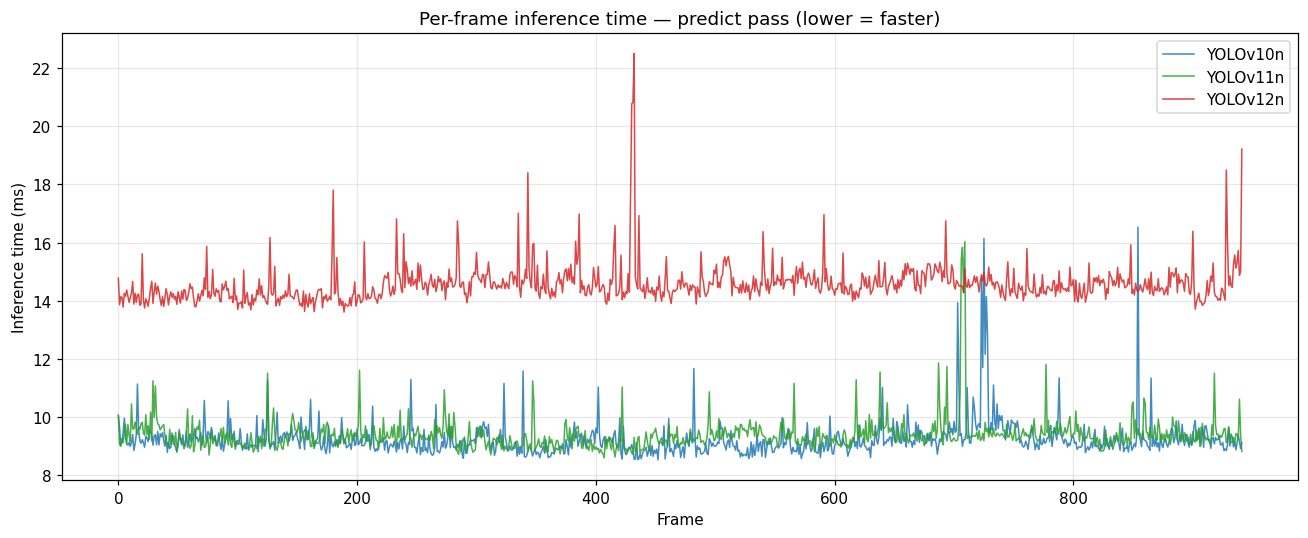

Saved: /kaggle/working/plots/01_per_frame_inference_predict.png


In [9]:
matplotlib.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 130})
color_map = {'YOLOv10n': '#1f77b4', 'YOLOv11n': '#2ca02c', 'YOLOv12n': '#d62728'}

# 8.1 Per-frame inference time (predict)
plt.figure(figsize=(12, 5))
for name, df in predict_dfs.items():
    plt.plot(df['frame'], df['inference_ms'], label=name,
             color=color_map.get(name), linewidth=1.0, alpha=0.85)
plt.xlabel('Frame')
plt.ylabel('Inference time (ms)')
plt.title('Per-frame inference time — predict pass (lower = faster)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
p = PLOTS_DIR / '01_per_frame_inference_predict.png'
plt.savefig(p); plt.show(); print('Saved:', p)

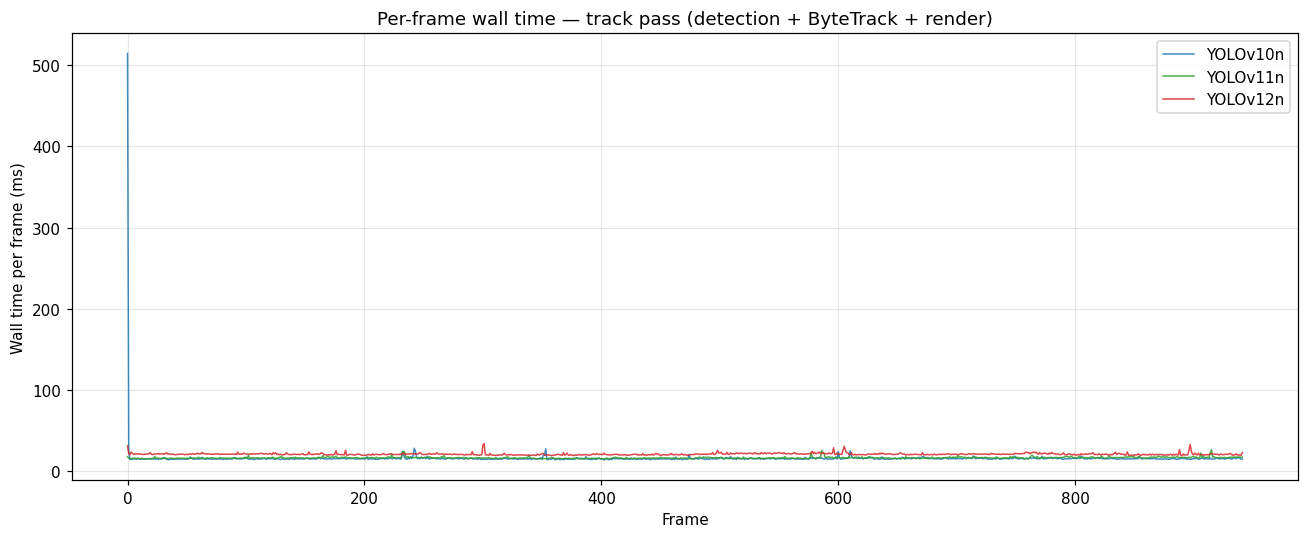

Saved: /kaggle/working/plots/02_per_frame_wall_track.png


In [10]:
# 8.2 Per-frame wall time (track)
plt.figure(figsize=(12, 5))
for name, df in track_dfs.items():
    plt.plot(df['frame'], df['wall_ms'], label=name,
             color=color_map.get(name), linewidth=1.0, alpha=0.85)
plt.xlabel('Frame')
plt.ylabel('Wall time per frame (ms)')
plt.title('Per-frame wall time — track pass (detection + ByteTrack + render)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
p = PLOTS_DIR / '02_per_frame_wall_track.png'
plt.savefig(p); plt.show(); print('Saved:', p)

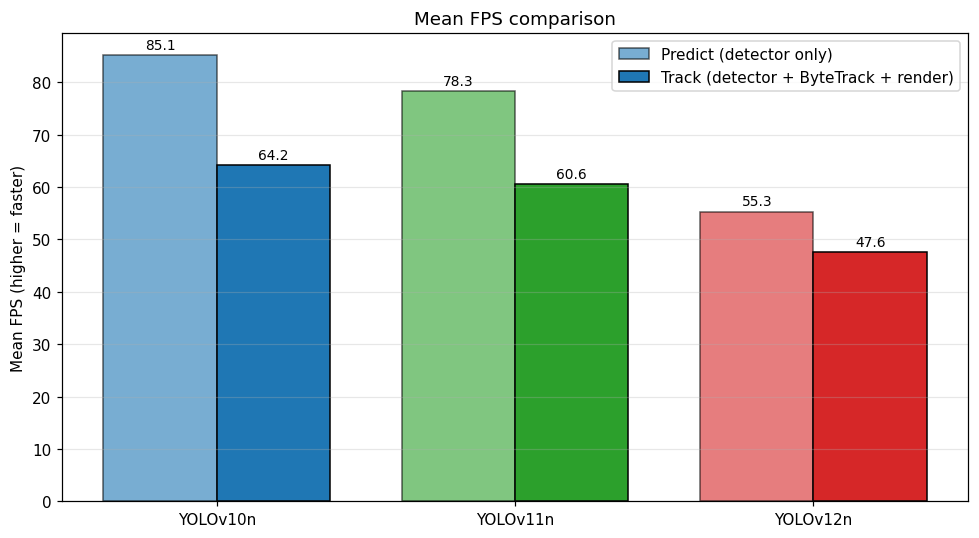

Saved: /kaggle/working/plots/03_mean_fps_bars.png


In [11]:
# 8.3 Mean FPS bar chart (predict vs track)
names = list(predict_dfs.keys())
predict_fps = [predict_dfs[n]['fps_wall'].mean() for n in names]
track_fps   = [track_dfs[n]['fps_wall'].mean()   for n in names]

x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, predict_fps, w, label='Predict (detector only)',
            color=[color_map[n] for n in names], alpha=0.6, edgecolor='black')
b2 = ax.bar(x + w/2, track_fps,   w, label='Track (detector + ByteTrack + render)',
            color=[color_map[n] for n in names], alpha=1.0, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Mean FPS (higher = faster)')
ax.set_title('Mean FPS comparison')
ax.legend()
for bars in (b1, b2):
    for r in bars:
        ax.annotate(f'{r.get_height():.1f}',
                    xy=(r.get_x() + r.get_width()/2, r.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
p = PLOTS_DIR / '03_mean_fps_bars.png'
plt.savefig(p); plt.show(); print('Saved:', p)

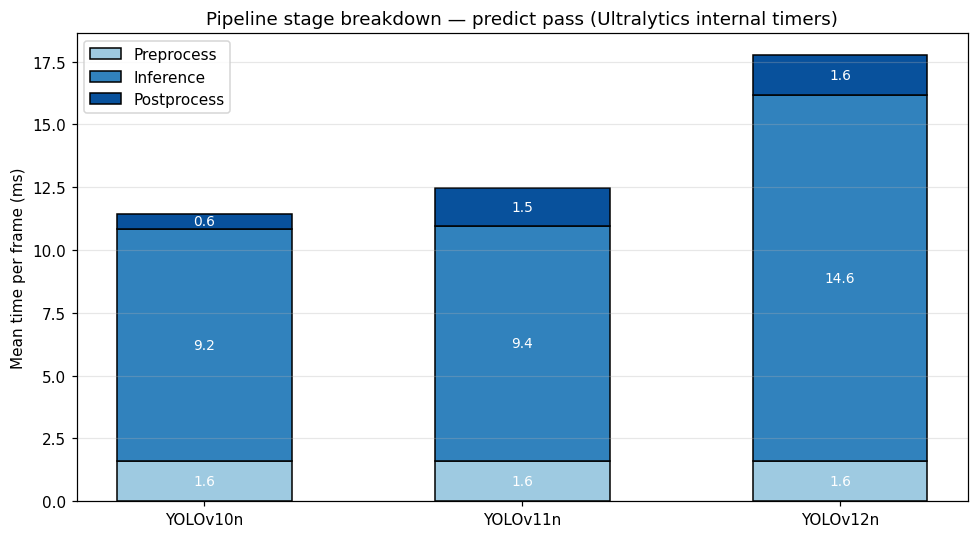

Saved: /kaggle/working/plots/04_stage_breakdown.png


In [12]:
# 8.4 Stage breakdown (preprocess / inference / postprocess)
stages = ['preprocess_ms', 'inference_ms', 'postprocess_ms']
stage_labels = ['Preprocess', 'Inference', 'Postprocess']
data = {s: [predict_dfs[n][s].mean() for n in names] for s in stages}

x = np.arange(len(names)); bottom = np.zeros(len(names))
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#9ecae1', '#3182bd', '#08519c']
for stage, label, c in zip(stages, stage_labels, colors):
    vals = np.array(data[stage])
    ax.bar(x, vals, 0.55, bottom=bottom, label=label, color=c, edgecolor='black')
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.4:
            ax.text(xi, b + v/2, f'{v:.1f}', ha='center', va='center',
                    color='white', fontsize=9)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Mean time per frame (ms)')
ax.set_title('Pipeline stage breakdown — predict pass (Ultralytics internal timers)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
p = PLOTS_DIR / '04_stage_breakdown.png'
plt.savefig(p); plt.show(); print('Saved:', p)

/tmp/ipykernel_22/3606486689.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=names, showmeans=True, patch_artist=True)


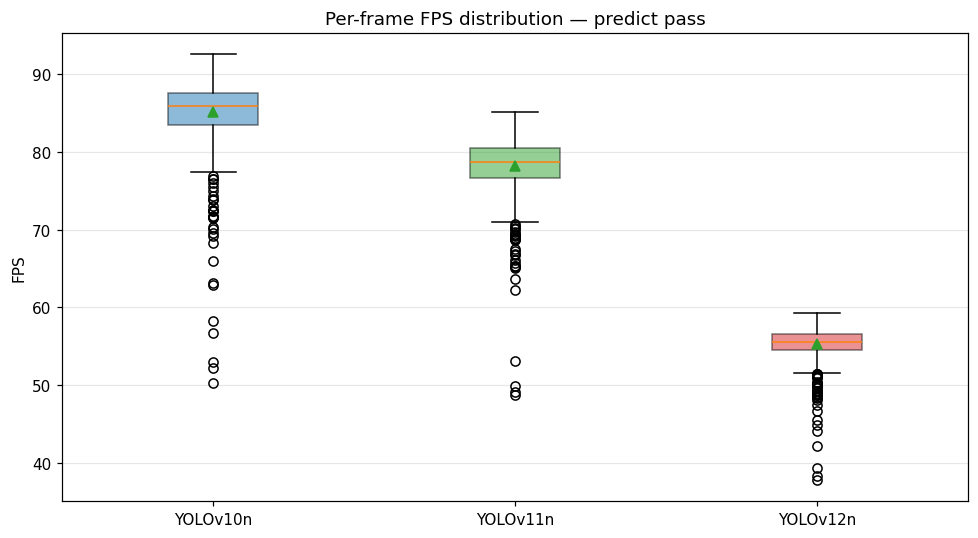

Saved: /kaggle/working/plots/05_fps_boxplot_predict.png


In [13]:
# 8.5 FPS distribution boxplot (predict)
fig, ax = plt.subplots(figsize=(9, 5))
data_box = [predict_dfs[n]['fps_wall'].values for n in names]
bp = ax.boxplot(data_box, labels=names, showmeans=True, patch_artist=True)
for patch, n in zip(bp['boxes'], names):
    patch.set_facecolor(color_map[n]); patch.set_alpha(0.5)
ax.set_ylabel('FPS'); ax.set_title('Per-frame FPS distribution — predict pass')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
p = PLOTS_DIR / '05_fps_boxplot_predict.png'
plt.savefig(p); plt.show(); print('Saved:', p)

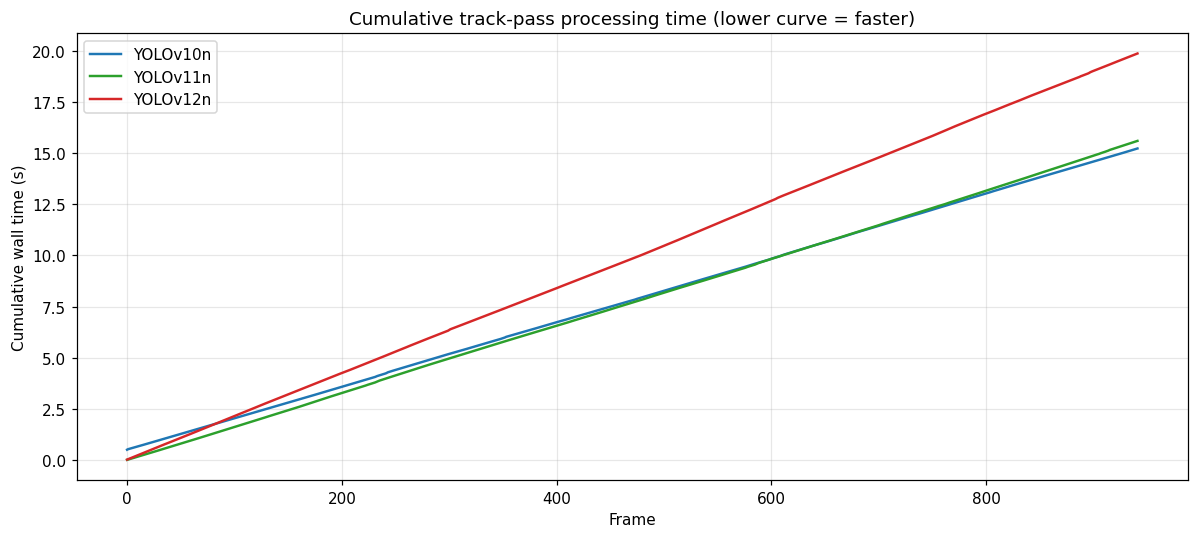

Saved: /kaggle/working/plots/06_cumulative_time_track.png


In [14]:
# 8.6 Cumulative processing time (track pass)
plt.figure(figsize=(11, 5))
for name, df in track_dfs.items():
    cum = np.cumsum(df['wall_ms'].values) / 1000.0
    plt.plot(df['frame'], cum, label=name,
             color=color_map.get(name), linewidth=1.6)
plt.xlabel('Frame'); plt.ylabel('Cumulative wall time (s)')
plt.title('Cumulative track-pass processing time (lower curve = faster)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
p = PLOTS_DIR / '06_cumulative_time_track.png'
plt.savefig(p); plt.show(); print('Saved:', p)

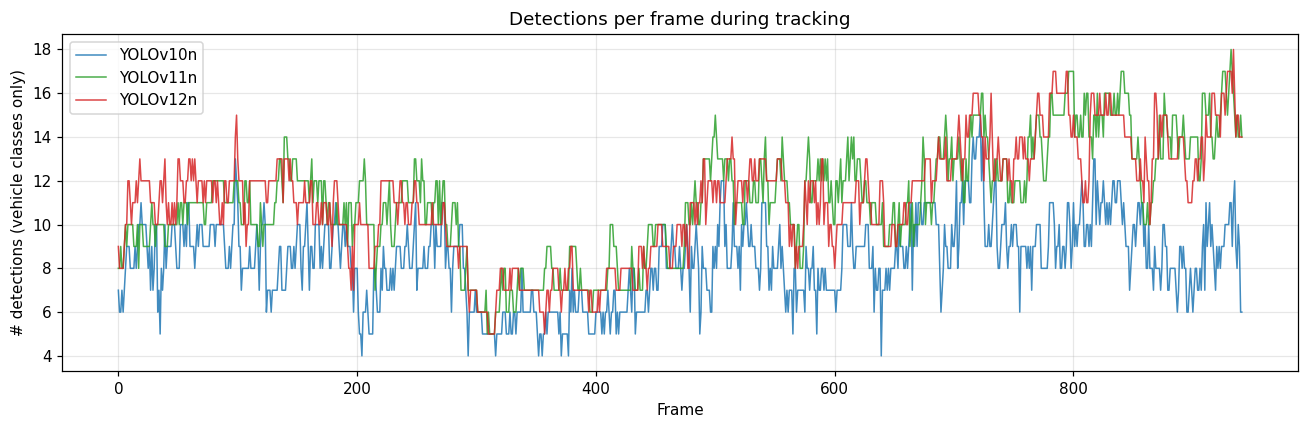

Saved: /kaggle/working/plots/07_detections_per_frame.png


In [15]:
# 8.7 Detections per frame
plt.figure(figsize=(12, 4))
for name, df in track_dfs.items():
    plt.plot(df['frame'], df['detections'], label=name,
             color=color_map.get(name), linewidth=1.0, alpha=0.85)
plt.xlabel('Frame'); plt.ylabel('# detections (vehicle classes only)')
plt.title('Detections per frame during tracking')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
p = PLOTS_DIR / '07_detections_per_frame.png'
plt.savefig(p); plt.show(); print('Saved:', p)

## 9. Sample Annotated Frames

One mid-video frame per model, side by side.

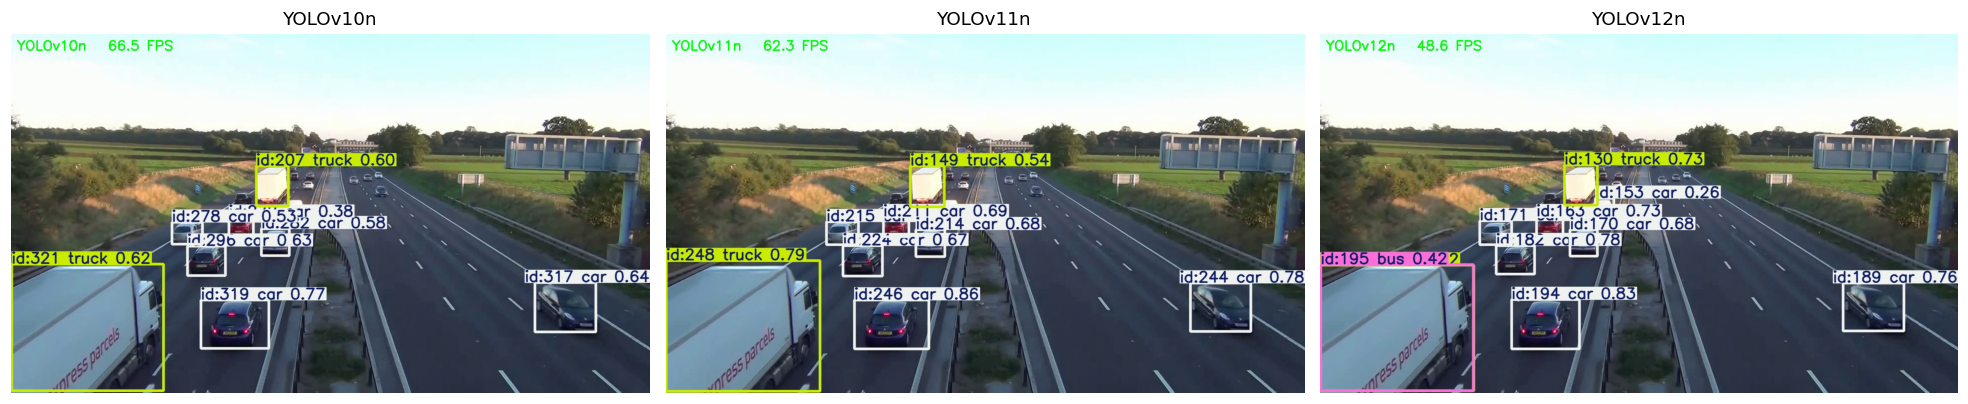

Saved: /kaggle/working/plots/08_sample_frames.png


In [16]:
sample_imgs = {}
for name in MODELS:
    vid = OUTPUT_DIR / f'{name}_tracked.mp4'
    if not vid.exists():
        continue
    cap = cv2.VideoCapture(str(vid))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, n // 2))
    ok, fr = cap.read()
    cap.release()
    if ok:
        sample_imgs[name] = cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)
        cv2.imwrite(str(FRAMES_DIR / f'{name}_midframe.jpg'), fr)

if sample_imgs:
    fig, axes = plt.subplots(1, len(sample_imgs), figsize=(6 * len(sample_imgs), 5))
    if len(sample_imgs) == 1:
        axes = [axes]
    for ax, (name, img) in zip(axes, sample_imgs.items()):
        ax.imshow(img); ax.set_title(name); ax.axis('off')
    plt.tight_layout()
    p = PLOTS_DIR / '08_sample_frames.png'
    plt.savefig(p); plt.show(); print('Saved:', p)
else:
    print('No tracked videos available to sample.')

## 10. Written Report

In [17]:
def fmt_pct_diff(a, b):
    if a is None or b is None or a == 0:
        return 'n/a'
    return f'{(b - a) / a * 100:+.1f}%'


baseline = 'YOLOv10n' if 'YOLOv10n' in track_dfs else next(iter(track_dfs), None)

lines = []
lines.append('# YOLOv10n vs YOLOv11n vs YOLOv12n — Tracking Speed Report\n')
lines.append('## 1. Setup\n')
lines.append(f'- Video: `{INPUT_VIDEO}`')
lines.append(f"- Resolution: {VIDEO_META['width']}x{VIDEO_META['height']}, "
             f"{VIDEO_META['fps']:.2f} fps source, {VIDEO_META['frame_count']} frames "
             f"(~{VIDEO_META['duration_sec']:.1f} s)")
lines.append(f'- Device: `{DEVICE}`  |  half precision: `{HALF}`  |  imgsz: `{IMG_SIZE}`')
lines.append(f'- Tracker: `{TRACKER}` (held constant across all detectors)')
lines.append(f'- Vehicle classes only: {VEHICLE_CLASSES} (COCO car/motorcycle/bus/truck)')
lines.append(f'- Warmup frames discarded: {WARMUP_FRAMES}')
lines.append(f'- Ultralytics: {ultralytics.__version__}, Torch: {torch.__version__}, '
             f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}\n")

if load_errors:
    lines.append('## 1a. Load failures\n')
    for k, v in load_errors.items():
        lines.append(f'- **{k}**: {v}')
    lines.append('')

if runtime_failures:
    lines.append('## 1b. Runtime failures\n')
    for k, v in runtime_failures.items():
        lines.append(f'- **{k}**: {v}')
    lines.append('')

lines.append('## 2. Headline numbers\n')
lines.append('| Model | Params | Predict FPS | Track FPS | Predict mean ms | Track mean ms | Track p95 ms | Tracks |')
lines.append('|---|---:|---:|---:|---:|---:|---:|---:|')
for name in MODELS:
    b = summary['models'].get(name)
    if not b or not b.get('predict') or not b.get('track'):
        lines.append(f'| {name} | — | — | — | — | — | — | — |')
        continue
    lines.append(
        f"| {name} | {b['params']:,} "
        f"| {b['predict']['fps_wall_mean']:.1f} "
        f"| {b['track']['fps_wall_mean']:.1f} "
        f"| {b['predict']['wall_ms_mean']:.2f} "
        f"| {b['track']['wall_ms_mean']:.2f} "
        f"| {b['track']['wall_ms_p95']:.2f} "
        f"| {b['unique_track_ids']} |"
    )
lines.append('')

if baseline and baseline in track_dfs:
    base_track_ms   = summary['models'][baseline]['track']['wall_ms_mean']
    base_predict_ms = summary['models'][baseline]['predict']['wall_ms_mean']
    lines.append(f'## 3. Relative to baseline ({baseline})\n')
    lines.append('| Model | Predict ms diff | Track ms diff |')
    lines.append('|---|---:|---:|')
    for name in MODELS:
        b = summary['models'].get(name)
        if not b or not b.get('track'):
            continue
        lines.append(
            f"| {name} "
            f"| {fmt_pct_diff(base_predict_ms, b['predict']['wall_ms_mean'])} "
            f"| {fmt_pct_diff(base_track_ms,   b['track']['wall_ms_mean'])} |"
        )
    lines.append('')

lines.append('## 4. Honest analysis\n')
lines.append(
    '- **Pure detector cost (`predict ms`)** is the cleanest signal. '
    'The track pass adds ByteTrack association, Kalman update, ID bookkeeping, '
    'annotation drawing, and `mp4` encode — collectively non-trivial and roughly constant across detectors.'
)
lines.append(
    '- **Variance matters.** Look at `p95` and the boxplot. A model with a slightly worse mean but tighter distribution '
    'is more useful in production than one with a great mean and a long tail.'
)
lines.append(
    '- **Detection counts** between the three models should be roughly similar. If one model diverges sharply, '
    'treat its FPS gap with suspicion — it may be doing less work, not faster work.'
)
lines.append(
    '- **Single-video benchmarks are weak.** These numbers are valid for *this* clip on *this* hardware. '
    'Do not generalize to absolute performance statements.'
)
lines.append('')

lines.append('## 5. Artifacts\n')
lines.append('- `speed_comparison.json` — full machine-readable summary')
lines.append('- `comparison_table.csv` — headline table')
lines.append('- `per_frame_logs/*.csv` — every frame timing for both passes')
lines.append('- `*_tracked.mp4` — annotated tracking video per model')
lines.append('- `plots/*.png` — all figures')
lines.append('- `sample_frames/*.jpg` — mid-video annotated frames')

report_md = '\n'.join(lines)
report_path = OUTPUT_DIR / 'REPORT.md'
report_path.write_text(report_md)
print('Saved:', report_path)
print('\n----- REPORT.md -----\n')
print(report_md)

Saved: /kaggle/working/REPORT.md

----- REPORT.md -----

# YOLOv10n vs YOLOv11n vs YOLOv12n — Tracking Speed Report

## 1. Setup

- Video: `/kaggle/input/datasets/amryasser226/test-video/Test.mp4`
- Resolution: 1280x720, 30.00 fps source, 942 frames (~31.4 s)
- Device: `0`  |  half precision: `True`  |  imgsz: `640`
- Tracker: `bytetrack.yaml` (held constant across all detectors)
- Vehicle classes only: [2, 3, 5, 7] (COCO car/motorcycle/bus/truck)
- Warmup frames discarded: 30
- Ultralytics: 8.4.45, Torch: 2.10.0+cu128, GPU: Tesla T4

## 2. Headline numbers

| Model | Params | Predict FPS | Track FPS | Predict mean ms | Track mean ms | Track p95 ms | Tracks |
|---|---:|---:|---:|---:|---:|---:|---:|
| YOLOv10n | 2,775,520 | 85.1 | 64.2 | 11.78 | 16.16 | 17.17 | 200 |
| YOLOv11n | 2,624,080 | 78.3 | 60.6 | 12.81 | 16.55 | 17.99 | 184 |
| YOLOv12n | 2,603,056 | 55.3 | 47.6 | 18.10 | 21.09 | 22.87 | 149 |

## 3. Relative to baseline (YOLOv10n)

| Model | Predict ms diff | Track ms diff |


## 11. Final Output Listing

In [18]:
for root, dirs, files in os.walk(OUTPUT_DIR):
    rel = os.path.relpath(root, OUTPUT_DIR)
    if rel == '.':
        rel = ''
    for f in sorted(files):
        full = os.path.join(root, f)
        size = os.path.getsize(full)
        size_h = (f'{size/1e6:.2f} MB' if size > 1e6
                  else f'{size/1e3:.1f} KB' if size > 1e3 else f'{size} B')
        print(f'  {os.path.join(rel, f):<60} {size_h}')

  REPORT.md                                                    2.2 KB
  YOLOv10n_tracked.mp4                                         33.63 MB
  YOLOv11n_tracked.mp4                                         36.82 MB
  YOLOv12n_tracked.mp4                                         36.25 MB
  __notebook__.ipynb                                           2.13 MB
  comparison_table.csv                                         317 B
  speed_comparison.json                                        4.8 KB
  yolo11n.pt                                                   5.61 MB
  yolo12n.pt                                                   5.60 MB
  yolov10n.pt                                                  5.86 MB
  plots/00_source_first_frame.png                              409.4 KB
  plots/01_per_frame_inference_predict.png                     196.2 KB
  plots/02_per_frame_wall_track.png                            73.7 KB
  plots/03_mean_fps_bars.png                                   42.6 KB
  plo

## 12. What this notebook does *not* prove

- **It does not prove one model is better than another in general.** It measures speed on one short motorway clip on whatever GPU Kaggle gave you.
- **It does not measure accuracy.** No mAP, no MOTA, no ID-F1. If accuracy matters, run a labelled eval.
- **It does not isolate ByteTrack overhead per model.** Tracker cost scales with detection count.
- **It does not control for thermal throttling.** Re-run with a cold GPU for a fair re-test.